Proposal Track 1 - Baseline
- Binary or count matrix
- Clustering: Hierarchical / k-means / HDBSCAN
- Answer: Can ACRs be classified into different types
based on CRE composition?


Preprocessing:
- Parsing FASTA coordinates and sequences with Biopython
- FIMO.gff was cleaned as follows: Ran Tomtom on .meme file against itself to assign to a grouping to extremely similar motifs, mapped groupings to FIMO.gff and collapsed overlapping motifs from same grouping

In [ ]:
from Bio import SeqIO
import pandas as pd

sequences = []
coords = []

#Fasta file for ACRs
for record in SeqIO.parse("/Users/avery/Downloads/dACR.fa", "fasta"):
    sequences.append(str(record.seq))
    coords.append(record.id)

gff = pd.read_csv(
    "/Users/avery/fimo_collapsed_with_metadata.csv"
)

def extract_alias(attr):
    for field in attr.split(";"):
        if field.startswith("Alias="):
            return field.split("=")[1]
    return None

gff["Alias"] = gff["attributes"].apply(extract_alias)
gff["sequence_id"] = gff["seqid"].astype(str).str.strip()

(57852, 18)


Binary Matrix

In [ ]:
#Binary matrix for motifs
binary_df = pd.crosstab(
    gff["sequence_id"],
    gff["Alias"]
)

binary_df = (binary_df > 0).astype(int)

binary_df = binary_df.reindex(
    coords,
    fill_value=0
)
print(binary_df.shape)


(31295, 28)


Count Matrix

In [56]:
from sklearn.preprocessing import normalize

#ACR by Motif Family count matrix
count_df = pd.crosstab(
    gff["sequence_id"],
    gff["Alias"]
)

count_df = count_df.reindex(
    coords,
    fill_value=0
)

#Sorted by total non-redundant motif intervals per ACR
count_df["Total_Motif_Intervals"] = count_df.sum(axis=1)
count_df = count_df.sort_values(by="Total_Motif_Intervals", ascending=False)

#Normalizing count matrix
count_df = pd.DataFrame(
    normalize(
        count_df.drop(columns=["Total_Motif_Intervals"]),
        norm="l1",
        axis=1
    ),
    index=count_df.index,
    columns=count_df.drop(columns=["Total_Motif_Intervals"]).columns
)
print(count_df.shape)

(31295, 28)


k-means binary and count clustering

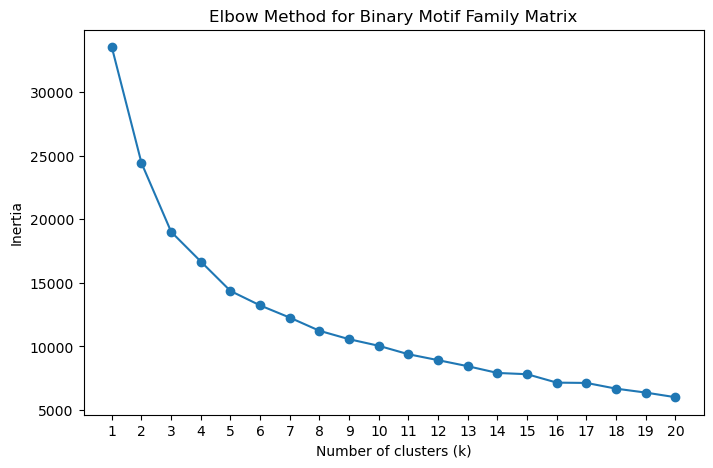

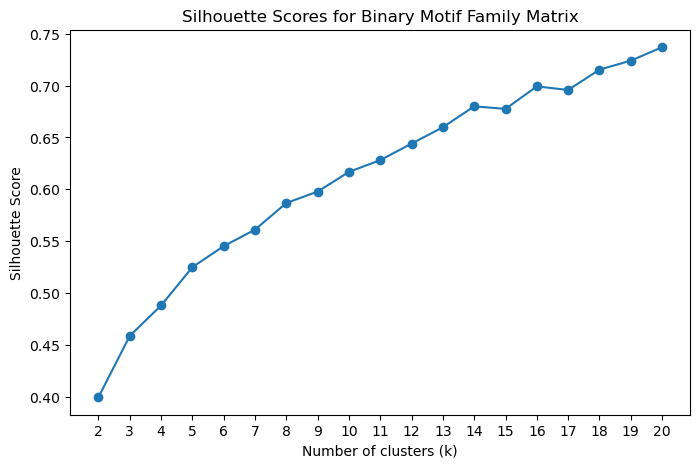

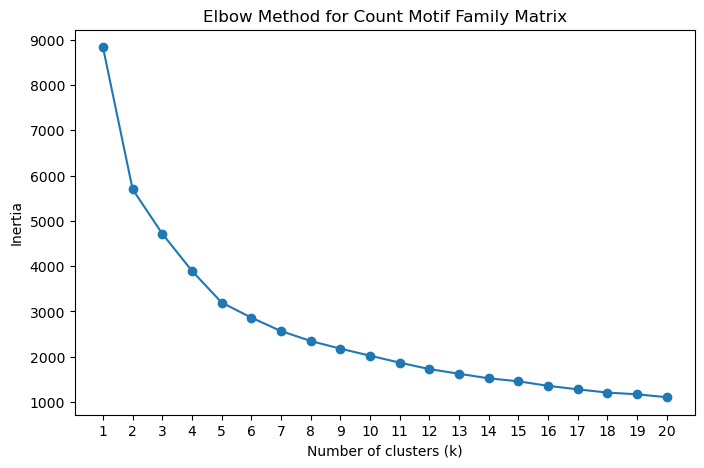

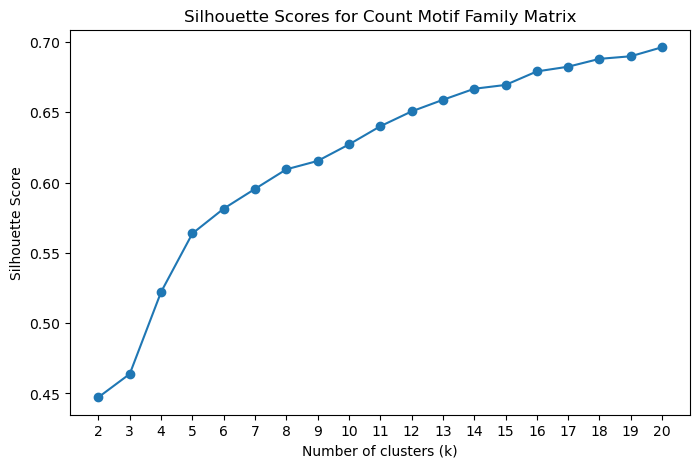

In [57]:
# K-means Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Feature matrices
X_binary = binary_df
X_count = count_df

K_range = range(1, 21)

##########################################################
# Binary matrix
##########################################################

# Elbow method
inertia = []

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    kmeans.fit(X_binary)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker="o")
plt.title("Elbow Method for Binary Motif Family Matrix")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.xticks(K_range)
plt.show()

# Silhouette analysis
silhouette_scores = []

for k in K_range[1:]:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_binary)

    silhouette_scores.append(
        silhouette_score(
            X_binary,
            labels
        )
    )

plt.figure(figsize=(8,5))
plt.plot(K_range[1:], silhouette_scores, marker="o")
plt.title("Silhouette Scores for Binary Motif Family Matrix")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(K_range[1:])
plt.show()

##########################################################
# Count matrix
##########################################################

# Elbow method
inertia_count = []

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    kmeans.fit(X_count)
    inertia_count.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia_count, marker="o")
plt.title("Elbow Method for Count Motif Family Matrix")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.xticks(K_range)
plt.show()

# Silhouette analysis
silhouette_scores_count = []

for k in K_range[1:]:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_count)

    silhouette_scores_count.append(
        silhouette_score(
            X_count,
            labels
        )
    )

plt.figure(figsize=(8,5))
plt.plot(K_range[1:], silhouette_scores_count, marker="o")
plt.title("Silhouette Scores for Count Motif Family Matrix")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(K_range[1:])
plt.show()

In [58]:
print("Binary matrix shape:", X_binary.shape)
print("Count matrix shape:", X_count.shape)

# Optimal k for binary matrix
kmeans_binary = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=20
)

binary_df["kmeans_cluster"] = kmeans_binary.fit_predict(X_binary)
print(binary_df["kmeans_cluster"].value_counts())

# Optimal k for count matrix
kmeans_count = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=20
)
count_df["kmeans_cluster"] = kmeans_count.fit_predict(X_count)
print(count_df["kmeans_cluster"].value_counts())

print("Binary matrix head:", binary_df.head())
print("Count matrix head:", count_df.head())    

Binary matrix shape: (31295, 28)
Count matrix shape: (31295, 28)
kmeans_cluster
3    14717
0     5747
2     4735
1     3388
4     2708
Name: count, dtype: int64
kmeans_cluster
3    13171
0     6025
2     4738
4     4545
1     2816
Name: count, dtype: int64
Binary matrix head: Alias              AGL6  AS2  AT4G12670  BPC1  BPC5  BPC6  CDF5  DOF1.5  \
sequence_id                                                               
Chr1_1948to3564       0    0          0     0     0     0     1       0   
Chr1_8549to9023       0    0          0     0     1     1     0       0   
Chr1_13478to14410     0    0          0     1     1     1     0       0   
Chr1_14678to15114     0    0          0     0     0     0     0       0   
Chr1_16429to16975     0    0          0     1     0     0     0       0   

Alias              DOF3.4  DOF3.6  ...  ERF2  ERF5  ERF9  NAC020  RAMOSA1  \
sequence_id                        ...                                      
Chr1_1948to3564         0       0  ...     

Hierarchical binary and count clustering

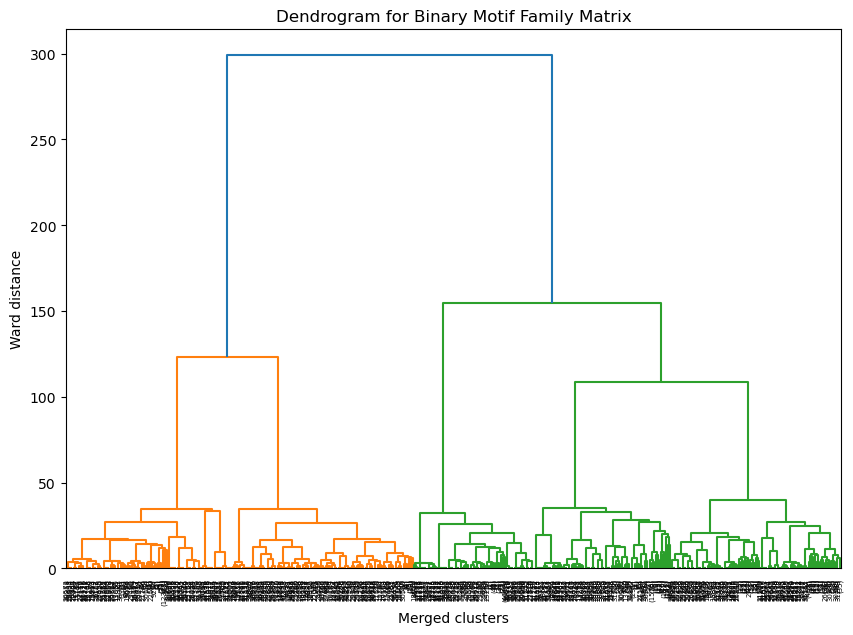

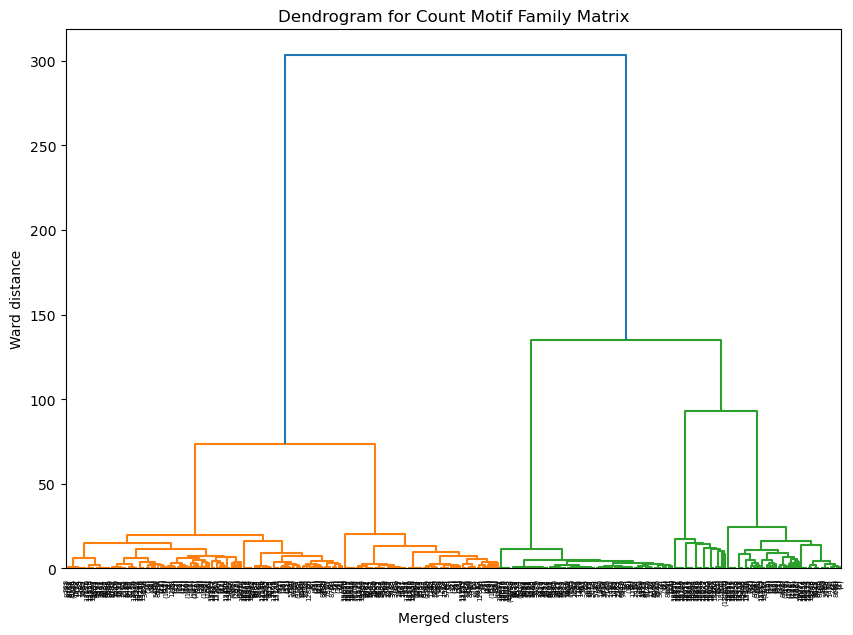

In [60]:
# Hierarchical Clustering
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

# Dendrogram for binary matrix
plt.figure(figsize=(10, 7))
sch.dendrogram(
    sch.linkage(X_binary, method="ward"),
    truncate_mode="level",
    p=10
)
plt.title("Dendrogram for Binary Motif Family Matrix")
plt.xlabel("Merged clusters")
plt.ylabel("Ward distance")
plt.show()

# Dendrogram for count matrix
plt.figure(figsize=(10, 7))
sch.dendrogram(
    sch.linkage(X_count, method="ward"),
    truncate_mode="level",
    p=10
)
plt.title("Dendrogram for Count Motif Family Matrix")
plt.xlabel("Merged clusters")
plt.ylabel("Ward distance")
plt.show()

In [66]:
from sklearn.cluster import AgglomerativeClustering

# Feature matrices (exclude metadata/cluster columns)
X_binary = binary_df.drop(
    columns=["kmeans_cluster", "hierarchical_cluster"],
    errors="ignore"
)

X_count = count_df.drop(
    columns=["Total_Motif_Intervals",
             "kmeans_cluster",
             "hierarchical_cluster"],
    errors="ignore"
)

# Hierarchical clustering for binary matrix
hierarchical_binary = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)

binary_df["hierarchical_cluster"] = hierarchical_binary.fit_predict(X_binary)

print(binary_df["hierarchical_cluster"].value_counts())

# Hierarchical clustering for count matrix
hierarchical_count = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)

count_df["hierarchical_cluster"] = hierarchical_count.fit_predict(X_count)

print(count_df["hierarchical_cluster"].value_counts())

hierarchical_cluster
3    12610
0     6641
1     4525
4     4059
2     3460
Name: count, dtype: int64
hierarchical_cluster
2    12932
1     9344
0     4352
3     4050
4      617
Name: count, dtype: int64


Cluster Stability and Sensitivity

In [68]:
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score
)

##########################################################
# KMEANS STABILITY
##########################################################

def kmeans_stability(X, n_clusters, runs=10):

    label_sets = []

    for seed in range(runs):

        labels = KMeans(
            n_clusters=n_clusters,
            random_state=seed,
            n_init=10
        ).fit_predict(X)

        label_sets.append(labels)

    ari_scores = []

    for i in range(runs):
        for j in range(i + 1, runs):

            ari_scores.append(
                adjusted_rand_score(
                    label_sets[i],
                    label_sets[j]
                )
            )

    return np.mean(ari_scores)

##########################################################
# EVALUATION
##########################################################

def evaluate(X, labels, representation, method):

    labels = np.asarray(labels)

    mask = labels != -1

    X_valid = X.loc[mask]
    labels_valid = labels[mask]

    cluster_sizes = (
        pd.Series(labels_valid)
        .value_counts()
    )

    if len(cluster_sizes) > 1:

        silhouette = silhouette_score(
            X_valid,
            labels_valid
        )

        calinski = calinski_harabasz_score(
            X_valid,
            labels_valid
        )

        davies = davies_bouldin_score(
            X_valid,
            labels_valid
        )

    else:

        silhouette = np.nan
        calinski = np.nan
        davies = np.nan

    if method == "KMeans":

        stability = kmeans_stability(
            X_valid,
            len(cluster_sizes)
        )

    else:

        stability = np.nan

    return {

        "Representation": representation,

        "Method": method,

        "Clusters":
            len(cluster_sizes),

        "Largest Cluster":
            cluster_sizes.max(),

        "Smallest Cluster":
            cluster_sizes.min(),

        "Silhouette":
            silhouette,

        "Calinski-Harabasz":
            calinski,

        "Davies-Bouldin":
            davies,

        "ARI Stability":
            stability
    }

results = []

##########################################################
# BINARY
##########################################################

results.append(
    evaluate(
        X_binary,
        binary_df["kmeans_cluster"],
        "Binary",
        "KMeans"
    )
)

results.append(
    evaluate(
        X_binary,
        binary_df["hierarchical_cluster"],
        "Binary",
        "Hierarchical"
    )
)

##########################################################
# COUNT
##########################################################

results.append(
    evaluate(
        X_count,
        count_df["kmeans_cluster"],
        "Count",
        "KMeans"
    )
)

results.append(
    evaluate(
        X_count,
        count_df["hierarchical_cluster"],
        "Count",
        "Hierarchical"
    )
)

##########################################################
# SAVE
##########################################################

results_df = pd.DataFrame(results)

results_df.to_csv(
    "cluster_evaluation_track1.csv",
    index=False
)

print(results_df)

  Representation        Method  Clusters  Largest Cluster  Smallest Cluster  \
0         Binary        KMeans         5            14717              2708   
1         Binary  Hierarchical         5            12610              3460   
2          Count        KMeans         5            13171              2816   
3          Count  Hierarchical         5            12932               617   

   Silhouette  Calinski-Harabasz  Davies-Bouldin  ARI Stability  
0    0.524981       10447.465121        1.297222       0.953004  
1    0.500900        6710.629591        1.695934            NaN  
2    0.563764       13792.314909        1.074193       0.980156  
3    0.539002       11664.484095        1.058325            NaN  


In [69]:
binary_unique = (
    binary_df.drop(
        columns=["kmeans_cluster",
                 "hierarchical_cluster"],
        errors="ignore"
    )
    .drop_duplicates()
    .shape[0]
)

count_unique = (
    count_df.drop(
        columns=["Total_Motif_Intervals",
                 "kmeans_cluster",
                 "hierarchical_cluster"],
        errors="ignore"
    )
    .drop_duplicates()
    .shape[0]
)

print("Unique binary profiles:", binary_unique)
print("Unique count profiles:", count_unique)

Unique binary profiles: 668
Unique count profiles: 2174


Biological Evaluation of Clusters:

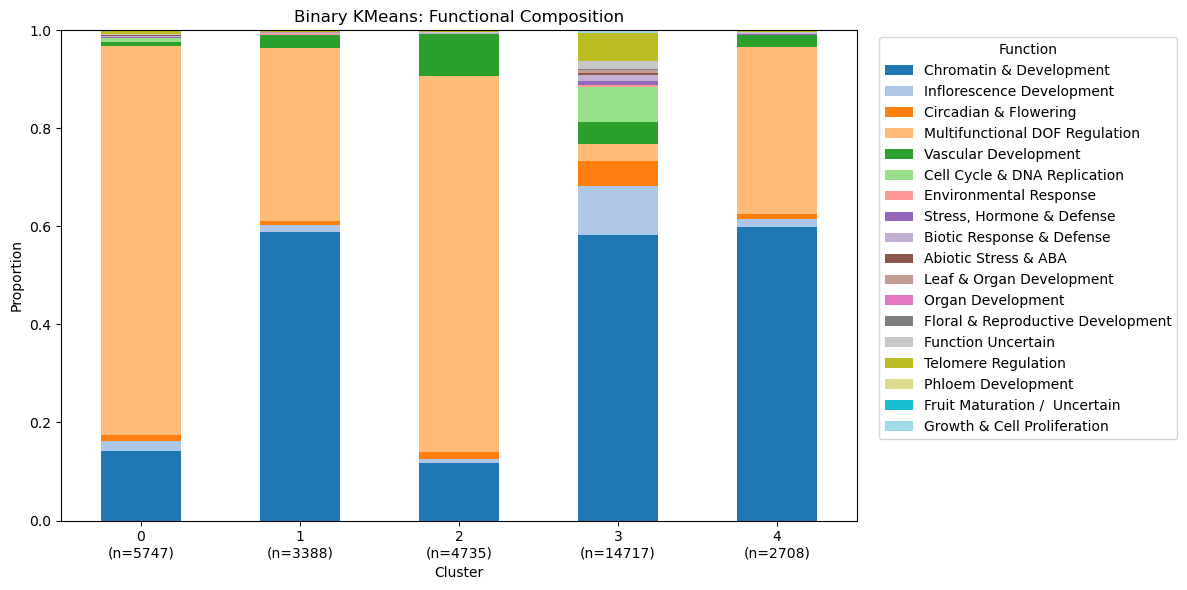

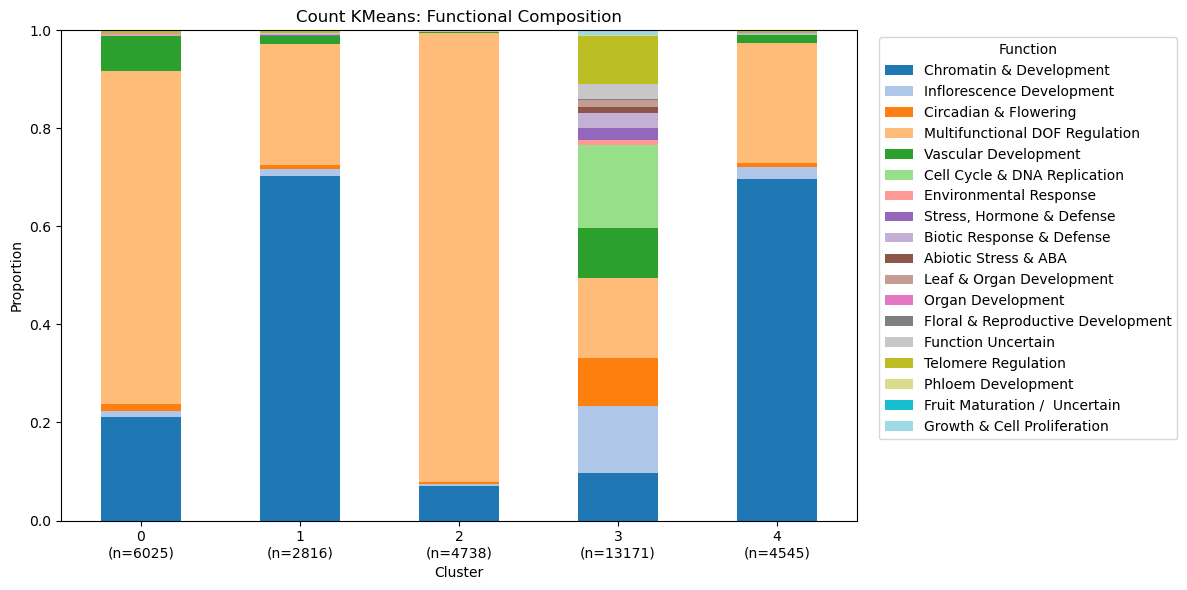

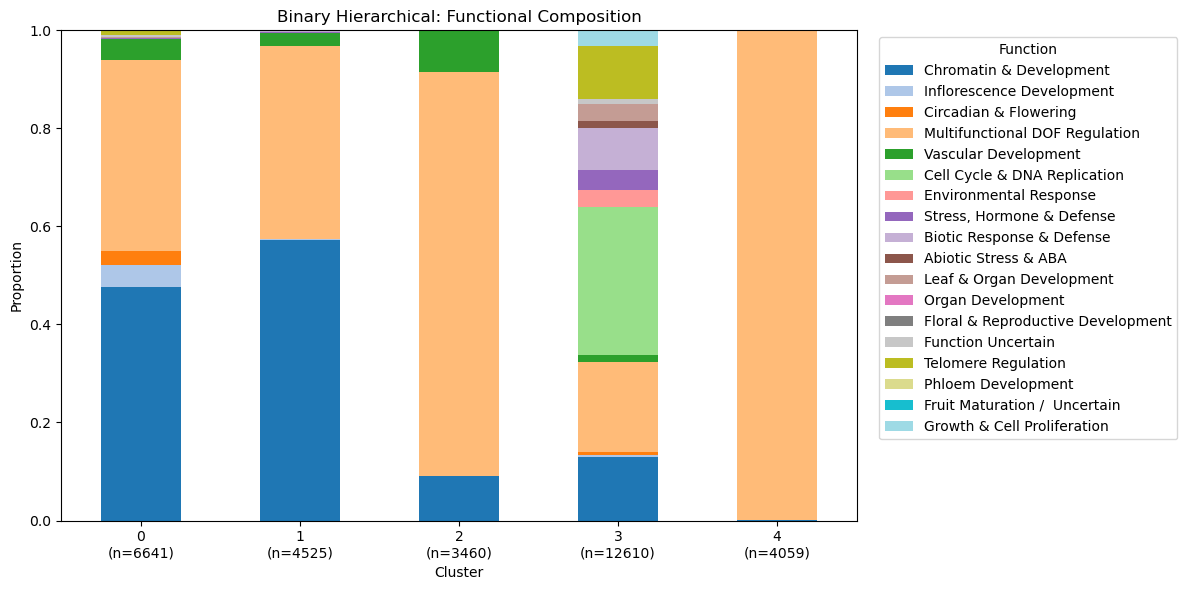

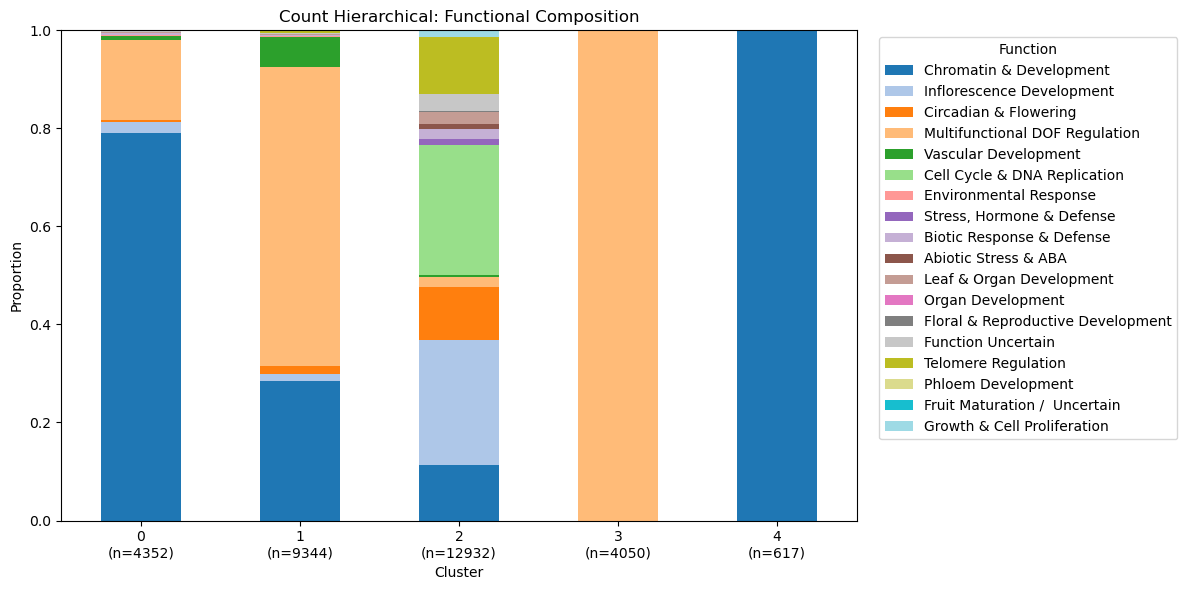

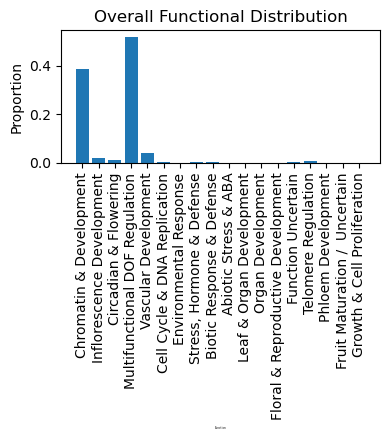

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

##########################################################
# FUNCTION DEFINITIONS
##########################################################

functional_groups = {
    'Chromatin & Development': ['BPC1', 'BPC5', 'BPC6'],
    'Inflorescence Development': ['RAMOSA1'],
    'Circadian & Flowering': ['CDF5'],
    'Multifunctional DOF Regulation': ['DOF3.6', 'DOF5.1', 'DOF3.4', 'DOF1.5'],
    'Vascular Development': ['DOF5.8'],
    'Cell Cycle & DNA Replication': ['E2FD', 'E2FE'],
    'Environmental Response': ['DREB2D', 'ERF095'],
    'Stress, Hormone & Defense': ['ERF014', 'ERF057', 'ERF091', 'ERF104', 'ERF2', 'ERF5'],
    'Biotic Response & Defense': ['ERF9'],
    'Abiotic Stress & ABA': ['RAP2-6'],
    'Leaf & Organ Development': ['AS2'],
    'Organ Development': ['LOB'],
    'Floral & Reproductive Development': ['AGL6'],
    'Function Uncertain': ['AT4G12670'],
    'Telomere Regulation': ['TRP1', 'TRP2'],
    'Phloem Development': ['NAC020'],
    'Fruit Maturation /  Uncertain': ['NAC058'],
    'Growth & Cell Proliferation': ['TCP14']
}

##########################################################
# CONSTANT FUNCTION ORDER
##########################################################

all_functions = list(functional_groups.keys())

##########################################################
# FUNCTIONAL COMPOSITION
##########################################################

def get_cluster_composition(cluster_labels):

    temp = gff.copy()

    temp["cluster"] = temp["sequence_id"].map(cluster_labels)

    temp = temp.dropna(subset=["Function", "cluster"])

    matrix = pd.crosstab(
        temp["cluster"],
        temp["Function"]
    )

    matrix = matrix.reindex(
        columns=all_functions,
        fill_value=0
    )

    proportions = matrix.div(
        matrix.sum(axis=1),
        axis=0
    )

    cluster_sizes = (
    cluster_labels
    .value_counts()
    .sort_index()
    )

    return proportions, cluster_sizes

##########################################################
# PLOTTING
##########################################################

def plot_stacked(df, cluster_sizes, title):

    ax = df.plot(
        kind="bar",
        stacked=True,
        figsize=(12,6),
        colormap="tab20"
    )
    labels = [
        f"{cluster}\n(n={cluster_sizes.loc[cluster]})"
        for cluster in df.index
    ]

    ax.set_xticklabels(labels, rotation=0)
    
    plt.ylabel("Proportion")
    plt.xlabel("Cluster")
    plt.title(title)
    plt.ylim(0,1)

    plt.legend(
        title="Function",
        bbox_to_anchor=(1.02,1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

##########################################################
# PLOTS
##########################################################

plots = [
    ("Binary KMeans", binary_df["kmeans_cluster"]),
    ("Count KMeans", count_df["kmeans_cluster"]),
    ("Binary Hierarchical", binary_df["hierarchical_cluster"]),
    ("Count Hierarchical", count_df["hierarchical_cluster"])
]

for title, labels in plots:

    composition, cluster_sizes = get_cluster_composition(labels)

    plot_stacked(
    composition,
    cluster_sizes,
    f"{title}: Functional Composition"
    )

##########################################################
# OVERALL FUNCTIONAL DISTRIBUTION
##########################################################

function_counts = (
    gff["Function"]
    .value_counts()
    .reindex(all_functions, fill_value=0)
)

function_prop = function_counts / function_counts.sum()

plt.figure(figsize=(4,4.5))

plt.bar(
    function_prop.index,
    function_prop.values
)

plt.ylabel("Proportion")
plt.xlabel("Function")
plt.title("Overall Functional Distribution")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import chi2_contingency
from scipy.stats import entropy

##########################################################
# Functional EVALUATION
##########################################################

def biological_summary(cluster_labels, representation, method):
    
    temp = gff.copy()
    temp["cluster"] = temp["sequence_id"].map(cluster_labels)
    temp = temp.dropna(subset=["Function", "cluster"])

    ######################################################
    # Cluster sizes (number of ACRs)
    ######################################################
    cluster_sizes = (
        cluster_labels
        .value_counts()
        .sort_index()
    )

    ######################################################
    # Contingency table
    ######################################################
    counts = (
        pd.crosstab(
            temp["cluster"],
            temp["Function"]
        )
        .reindex(columns=all_functions, fill_value=0)
    )

    ######################################################
    # Chi-square
    ######################################################
    chi_counts = counts.loc[:, counts.sum(axis=0) > 0]
    chi2, p, dof, expected = chi2_contingency(chi_counts)

    ######################################################
    # Proportions
    ######################################################
    proportions = counts.div(
        counts.sum(axis=1),
        axis=0
    )

    ######################################################
    # Summary table
    ######################################################
    rows = []

    for cluster in proportions.index:

        top3 = (
            proportions.loc[cluster]
            .sort_values(ascending=False)
            .head(3)
        )
        
        ######################################################
        # Shannon diversity
        ######################################################
        shannon = entropy(
            proportions.loc[cluster],
            base=2
        )

        rows.append({

            "Representation": representation,

            "Method": method,

            "Chi-square p": "<0.001" if p < 0.001 else f"{p:.3f}",

            "Cluster": cluster,

            "Cluster Size (ACRs)": int(cluster_sizes.loc[cluster]),

            "Shannon Diversity Index": round(shannon, 3),

            "Top Function 1": top3.index[0],
            "Top 1 (%)": round(top3.iloc[0] * 100, 2),

            "Top Function 2": top3.index[1],
            "Top 2 (%)": round(top3.iloc[1] * 100, 2),

            "Top Function 3": top3.index[2],
            "Top 3 (%)": round(top3.iloc[2] * 100, 2)

        })

    return pd.DataFrame(rows)

##########################################################
# RUN
##########################################################
bio_results = pd.concat([

    biological_summary(
        binary_df["kmeans_cluster"],
        "Binary",
        "KMeans"
    ),

    biological_summary(
        binary_df["hierarchical_cluster"],
        "Binary",
        "Hierarchical"
    ),

    biological_summary(
        count_df["kmeans_cluster"],
        "Count",
        "KMeans"
    ),

    biological_summary(
        count_df["hierarchical_cluster"],
        "Count",
        "Hierarchical"
    )

], ignore_index=True)

bio_results.to_csv(
    "track1_biological_summary.csv",
    index=False
)

print(bio_results)

   Representation        Method Chi-square p  Cluster  Cluster Size (ACRs)  \
0          Binary        KMeans       <0.001        0                 5747   
1          Binary        KMeans       <0.001        1                 3388   
2          Binary        KMeans       <0.001        2                 4735   
3          Binary        KMeans       <0.001        3                14717   
4          Binary        KMeans       <0.001        4                 2708   
5          Binary  Hierarchical       <0.001        0                 6641   
6          Binary  Hierarchical       <0.001        1                 4525   
7          Binary  Hierarchical       <0.001        2                 3460   
8          Binary  Hierarchical       <0.001        3                12610   
9          Binary  Hierarchical       <0.001        4                 4059   
10          Count        KMeans       <0.001        0                 6025   
11          Count        KMeans       <0.001        1           

Abbreviating function names so that the functional distribution plot fits more concisely into research paper:

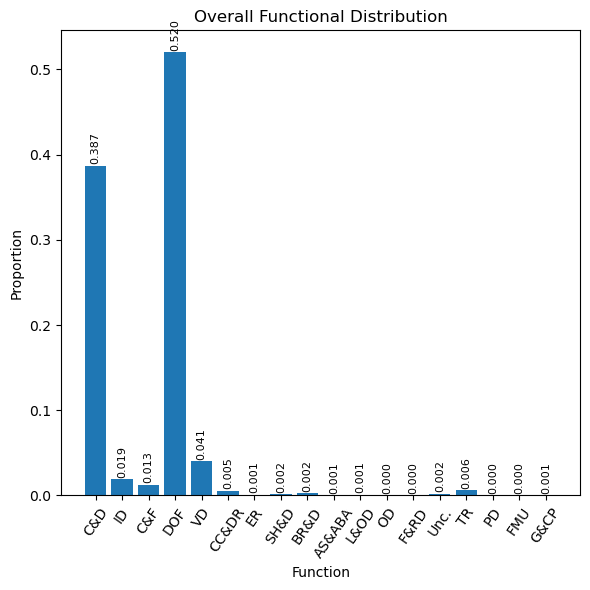

In [ ]:
# Abbreviations for plotting
function_abbrev = {
    "Chromatin & Development": "C&D",
    "Inflorescence Development": "ID",
    "Circadian & Flowering": "C&F",
    "Multifunctional DOF Regulation": "DOF",
    "Vascular Development": "VD",
    "Cell Cycle & DNA Replication": "CC&DR",
    "Environmental Response": "ER",
    "Stress, Hormone & Defense": "SH&D",
    "Biotic Response & Defense": "BR&D",
    "Abiotic Stress & ABA": "AS&ABA",
    "Leaf & Organ Development": "L&OD",
    "Organ Development": "OD",
    "Floral & Reproductive Development": "F&RD",
    "Function Uncertain": "Unc.",
    "Telomere Regulation": "TR",
    "Phloem Development": "PD",
    "Fruit Maturation /  Uncertain": "FMU",
    "Growth & Cell Proliferation": "G&CP"
}

function_counts = (
    gff["Function"]
    .value_counts()
    .reindex(all_functions, fill_value=0)
)

function_prop = function_counts / function_counts.sum()

# Convert long names to abbreviations for plotting
plot_labels = [function_abbrev[f] for f in function_prop.index]

plt.figure(figsize=(6,6))

bars = plt.bar(
    plot_labels,
    function_prop.values
)

plotlabs = plt.bar_label(
    bars,
    labels=[f"{p:.3f}" for p in function_prop],
    padding=1,
    fontsize=8
)
for label in plotlabs:
    label.set_rotation(90) #for vertical orientation of the bar labels

plt.ylabel("Proportion")
plt.xlabel("Function")
plt.title("Overall Functional Distribution")
plt.xticks(rotation=55)

plt.tight_layout()
plt.show()